In [2]:
from PyAnsatzEvolve import stateAnsatzManager, loadPath, loadParameters,readCsvState,loadOperators,loadNuclearEnergy
import numpy as np
import os
import matplotlib.pyplot as plt


In [106]:
def CanonicaliseAngles(man,Angles,operators, SDSPositions, InitialStateCoeffs, InitialStateIndices, invertSignOfWavefunction = False):
    """
       man - is the setup stateAnsatzManager
       Angles - are the angles for the ansatz
       SDSPositions - Lists of positions which form an SDS in the first layer. e.g. [[[1,2],[3],[4,5]],...]
       InitialStateCoeffs, InitialStateIndices - The initial state
    """ 

    assert(len(InitialStateCoeffs) == len(InitialStateIndices) and len(InitialStateIndices) == 1)
    managedToInvertWaveFuctionSign = False
    Angles = np.array(Angles).copy()

    man.setAngles(Angles)
    EnergyBefore = man.getExpectationValue()
    stateBefore = man.getFinalState()
    #print(f"Angles before {Angles}")

    InitialStateBitstring = InitialStateIndices[0]
    for loop in range(2):
        for i,L in enumerate(SDSPositions):
            #We implement v = EXC sin(-theta)  + (1-cos(-theta)) Exc^2 as the rotation. See Manual.md
            #To fix this we invert the signs here. 

            Angle1 = -Angles[L[0][0]] #S
            Angle2 = -Angles[L[1][0]] #D
            Angle3 = -Angles[L[2][0]] #S

            #scoping
            def check():
                #Check the assumptions
                doubleExc = operators[L[1][0]]
                S1 = operators[L[0][0]]
                S2 = operators[L[0][1]]
                S3 = operators[L[2][0]]
                S4 = operators[L[2][1]]
                #Check that the single double single structure has the spin operators together and not commuted or anything
                assert(S1 == S3 and S2 == S4)
                #Check that they are actually spin operators
                assert(S1 != S2 and S3 != S4)
                #Check that the double acts on the correct bits
                assert(set(doubleExc).union([0]) == set(S1).union(S2))
                #check that the double has the correct ordering and therefore phase
                assert(doubleExc[0] == S1[0] and doubleExc[1] == S2[0] and doubleExc[2] == S1[1] and doubleExc[3] == S2[1])
            check()
            
            
                                                    
            #Use the single excitations to determine the space we are acting on
            SpinDownAOs = [operators[L[0][0]][0]-1,operators[L[0][0]][1]-1]
            SpinUpAOs = [operators[L[0][1]][0]-1,operators[L[0][1]][1]-1]
            startVector = np.array([[0],[0],[0]],dtype=np.float64) # Isomorphism is X axis is 01|01, Y axis is 0.707 01|10 + 0.707 10|01, Z axis is 10|10
            InitialStateBitstringUnset = InitialStateBitstring ^ (InitialStateBitstring & ((1<<SpinDownAOs[0]) | (1<<SpinDownAOs[1]) | (1<<SpinUpAOs[0]) | (1<<SpinUpAOs[1])))
            
            #We are assuming this is a single configuration initial state and therefore we are never along the Y axis. 
            #SpinDownAOs[1] contains the annihilate position
            
            if InitialStateBitstring == (InitialStateBitstringUnset | (1<<SpinDownAOs[1]) | (1<<SpinUpAOs[1])): #X state 
                startVector[0,0] = 1.
            elif InitialStateBitstring == (InitialStateBitstringUnset | (1<<SpinDownAOs[0]) | (1<<SpinUpAOs[0])): #Z state
                startVector[2,0] = 1.
            elif InitialStateBitstring == (InitialStateBitstringUnset | (1<<SpinDownAOs[0]) | (1<<SpinUpAOs[1])) or \
                InitialStateBitstring == (InitialStateBitstringUnset | (1<<SpinDownAOs[1]) | (1<<SpinUpAOs[0])) : #Part of Y state
                assert(False) #Y state is not handled. 
            elif InitialStateBitstring == InitialStateBitstringUnset or \
                InitialStateBitstring == (InitialStateBitstring | ((1<<SpinDownAOs[0]) | (1<<SpinDownAOs[1]) | (1<<SpinUpAOs[0]) | (1<<SpinUpAOs[1]))):
                # if the bitstring is 0000 or 1111 then all the angles do nothing so set them to zero. 
                Angles[L[0][0]] = 0 #S Down
                Angles[L[0][1]] = 0 #S up
                Angles[L[1][0]] = 0 #D
                Angles[L[2][0]] = 0 #S Down
                Angles[L[2][1]] = 0 #S up
                continue
            else:
                #1 or 3 are set. Only the singles have an effect. Condense them down. 
                Angles[L[0][0]] += Angles[L[2][0]] #S Down
                # Angles[L[0][1]] += Angles[L[2][1]] #S up
                Angles[L[1][0]] = 0 #D
                Angles[L[2][0]] = 0 #S Down
                Angles[L[2][1]] = 0 #S up
                
                Angles[L[0][0]] = np.mod(Angles[L[0][0]],2*np.pi)
                #Keep the angle in the upper half plane, the negative half plane is related by a negative sign. this is [0,Pi]
                if loop == 0:
                    if Angles[L[0][0]] > np.pi:
                        managedToInvertWaveFuctionSign = not managedToInvertWaveFuctionSign
                        Angles[L[0][0]] -= np.pi
                elif managedToInvertWaveFuctionSign != invertSignOfWavefunction:
                    managedToInvertWaveFuctionSign = not managedToInvertWaveFuctionSign
                    Angles[L[0][0]] += np.pi
                
                Angles[L[0][1]]  = Angles[L[0][0]] 
                continue
            
            #find the resultant vector:
            #Setup rotation generators
            Kappa1 = np.array([[0,-np.sqrt(2),0],[np.sqrt(2),0,-np.sqrt(2)],[0,np.sqrt(2),0]]) # single exc
            Kappa2 = np.array([[0,0,-2],[0,0,0],[2,0,0]],dtype=np.float64) # double exc
            resultVector = np.array(startVector.copy())
            

            resultVector += 0.5*np.sin(2*Angle1)*Kappa1@resultVector + 0.25*(1-np.cos(2*Angle1)) * Kappa1 @ Kappa1 @ resultVector
            resultVector += 0.5*np.sin(Angle2)*Kappa2@resultVector + 0.25*(1-np.cos(Angle2)) * Kappa2 @ Kappa2 @ resultVector
            resultVector += 0.5*np.sin(2*Angle3)*Kappa1@resultVector + 0.25*(1-np.cos(2*Angle3)) * Kappa1 @ Kappa1 @ resultVector
            
            if loop == 0:
                if resultVector[0] + resultVector[1] + resultVector[2] < 0:
                    resultVector *= -1
                    managedToInvertWaveFuctionSign = not managedToInvertWaveFuctionSign
            elif managedToInvertWaveFuctionSign != invertSignOfWavefunction:
                resultVector *= -1
                managedToInvertWaveFuctionSign = not managedToInvertWaveFuctionSign
            

            #We now need to get back to the starting vector while enforcing the SDS^{-1} structure
            
            #Magic algebra
            # The SDS^{-1} structure can be thought of as doing the kappa2 rotation in a modified X' Z' plane. 
            # Find the angle of the S required such that Y'.startVector = Y'.endVector. There are two such angles at pi apart. Pick the smaller one

            # theta1 = -np.atan2((resultVector[1,0]-startVector[1,0])*np.sqrt(2),startVector[2,0]-startVector[0,0]+resultVector[0,0]-resultVector[2,0])/2
            theta1 = -np.atan(((resultVector[1,0]-startVector[1,0])*np.sqrt(2))/(startVector[2,0]-startVector[0,0]+resultVector[0,0]-resultVector[2,0]))/2
            XPrime = 0.5*np.sin(-2*theta1)*Kappa1@[[1],[0],[0]] + 0.25*(1-np.cos(-2*theta1)) * Kappa1 @ Kappa1 @ [[1],[0],[0]] + [[1],[0],[0]]
            YPrime = 0.5*np.sin(-2*theta1)*Kappa1@[[0],[1],[0]] + 0.25*(1-np.cos(-2*theta1)) * Kappa1 @ Kappa1 @ [[0],[1],[0]] + [[0],[1],[0]]
            ZPrime = 0.5*np.sin(-2*theta1)*Kappa1@[[0],[0],[1]] + 0.25*(1-np.cos(-2*theta1)) * Kappa1 @ Kappa1 @ [[0],[0],[1]] + [[0],[0],[1]]
            SX,SZ = np.dot(startVector[:,0],XPrime[:,0]),np.dot(startVector[:,0],ZPrime[:,0])
            VX,VZ = np.dot(resultVector[:,0],XPrime[:,0]),np.dot(resultVector[:,0],ZPrime[:,0])
            
            assert(np.isclose(np.dot(startVector[:,0],YPrime[:,0]), np.dot(resultVector[:,0],YPrime[:,0]))) # ,"Y'.V == Y'.S is false" 

            XZPrimeAngleStart = np.atan2(SZ,SX)
            XZPrimeAngleEnd = np.atan2(VZ,VX)
            theta2 = XZPrimeAngleEnd - XZPrimeAngleStart
            if theta2 > np.pi:
                theta2 = theta2 - 2*np.pi 
            elif theta2 < -np.pi:
                theta2 = theta2 + 2*np.pi 

            #Check that theta1 and theta2 take us to the correct vector
            resultVector2 = np.array(startVector.copy())
            resultVector2 += 0.5*np.sin(2*theta1)*Kappa1@resultVector2 + 0.25*(1-np.cos(2*theta1)) * Kappa1 @ Kappa1 @ resultVector2
            resultVector2 += 0.5*np.sin(theta2)*Kappa2@resultVector2 + 0.25*(1-np.cos(theta2)) * Kappa2 @ Kappa2 @ resultVector2
            resultVector2 += 0.5*np.sin(-2*theta1)*Kappa1@resultVector2 + 0.25*(1-np.cos(-2*theta1)) * Kappa1 @ Kappa1 @ resultVector2

            # print(f"err{resultVector2 - resultVector}")
            #We implement -EXC as the rotation
            Angles[L[0][0]] = -theta1 #S Down
            Angles[L[0][1]] = -theta1 #S up
            Angles[L[1][0]] = -theta2 #D
            Angles[L[2][0]] = theta1 #S Down
            Angles[L[2][1]] = theta1 #S up
                


    # print(f"Angles After {Angles}")
    man.setAngles(Angles)
    EnergyAfter = man.getExpectationValue()
    
    # print(f"Energy before: {EnergyBefore} Energy after: {EnergyAfter} Diff: {EnergyAfter - EnergyBefore}")
    if invertSignOfWavefunction:
        assert(managedToInvertWaveFuctionSign)
        stateAfter = man.getFinalState()
        assert(np.isclose(np.dot(stateBefore,stateAfter),-1))
    else:
        assert(not managedToInvertWaveFuctionSign)
        stateAfter = man.getFinalState()
        if not np.isclose(np.dot(stateBefore,stateAfter),1):
            print(np.dot(stateBefore,stateAfter))
        assert(np.isclose(np.dot(stateBefore,stateAfter),1))
    return Angles

def readNebCoordsFile(filename,NumParameters):
    ParameterList = []
    pos = 0
    numberOfCols = -1
    with open(filename) as f:
        for line in f:            
            ParametersOnThisLine = [float(l) for l in line.split()]
            if numberOfCols == -1:
                numberOfCols = len(ParametersOnThisLine)
                for i in range(numberOfCols):
                    ParameterList.append([])
            for i,p in enumerate(ParametersOnThisLine):
                ParameterList[i].append(p)
            pos = pos+1
    assert(pos == NumParameters)
    return ParameterList

def readNebEnergiesFile(filename,NumEnergies):
    Energies = []
    pos = 0
    
    with open(filename) as f:
        for line in f:            
            Energy = float(line)
            Energies.append(Energy)
            pos = pos+1
    assert(pos == NumEnergies)
    return Energies


In [102]:
PathBase = os.path.dirname(os.path.abspath('')) + "/Hams/H6_Tri_L2_28/"
NumParameters = 28


#Load a template path to know how long it will be.
templatePath = loadPath(PathBase + "qc_ucc.dat") # AKA qc_ucc.dat

#Load all the paths from the files. returns a tuple with:
# (rotationPaths,order,numberOfUniqueParameters)
# rotationPaths is a list of pairs of elements, first is the rotation (Deprecated, always zero), second is the angle
# order is a list of numbers representing parameter dependencies
# numberOfUnique parameters represents the total number of free angles

# AKA "qc_ucc_order.dat" and "lowest"
rotationPaths,order,constantOffset, numberOfUniqueParameters = loadParameters(PathBase + "qc_ucc_order.dat",PathBase + "_Parameters.dat",PathBase + "_OFFSET.dat",templatePath)
Angles = [[a[1] for a in p] for p in rotationPaths] # Extract the angles

#Load the initial state
# AKA qc_ucc_initial.dat
InitialState = readCsvState(PathBase + "qc_ucc_initial.dat")

#Sparsify the initial state. Currently we can only deal with one basis state at the start
InitialStateCoeffs = []
InitialStateIndices = []
for i,v in enumerate(InitialState):
    if v != 0:
        InitialStateCoeffs.append(v)
        InitialStateIndices.append(i)
assert(len(InitialStateCoeffs) == 1)

numberOfQubits = round(np.log2(len(InitialState)))

#Load the ansatz,
#AKA qc_ucc.dat
Operators = loadOperators(PathBase + "qc_ucc.dat")

#Setup the ansatzManager to be able to run circuits
man = stateAnsatzManager()
#Hamiltonians are loaded from "H4_Ham_Coeff.dat" and "H4_Ham_Index.dat" or "H4_oneEInts.bin" and "H4_twoEInts.bin"
man.storeRunPath(PathBase)
man.storeInitial(numberOfQubits,InitialStateIndices,InitialStateCoeffs)
man.storeOperators(Operators)
#Setup nuclear energy - not needed for now
# man.storeNuclearEnergy(loadNuclearEnergy("/home/bence/AnsatzEvolve/Hams/H4/L1/H4"))

man.storeParameterDependencies(order)

#Set some initial angles, defaults to zero if not set
#Hardcoded the SDS positions for the ansatz we are using, TODO determine this automatically its not trivial. 
SDSPositions = [[[0,1],[2],[3,4]],[[5,6],[7],[8,9]],[[10,11],[12],[13,14]]]

#Compute the canonical angles for this wavefunction and check
ParameterList = readNebCoordsFile(PathBase + "neb_coords",NumParameters)
Energies = readNebEnergiesFile(PathBase + "neb_energies",len(ParameterList))
ParameterList = np.array(ParameterList)

for i in range(len(ParameterList)):
    man.setAngles(ParameterList[i])
    Angles = man.getUncompressedAngles()
    Angles = CanonicaliseAngles(man,Angles,Operators,SDSPositions,InitialStateCoeffs,InitialStateIndices)
    man.setAngles(Angles)
    ParameterList[i,:] = man.getAngles()
for i in range(len(ParameterList)):
    man.setAngles(ParameterList[i])
    print(f"Energy found:{man.getExpectationValue()}, Expected:{Energies[i]}")









Energy found:-6.0254270369678125, Expected:-6.025427036968
Energy found:-6.024579750526669, Expected:-6.024579750527
Energy found:-6.025724990225028, Expected:-6.025724990225
Energy found:-5.943893892544859, Expected:-5.943893892545
Energy found:-6.052720744110619, Expected:-6.052720744111



Error in opening file.fileGiven: /Users/bence/AnsatzEvolve/Hams/H6_Tri_L2_28/_OFFSET.dat
warning assuming initial state starts with magnitude 1
m_InitialSZSym:: 1
m_OperatorSZSym:: 1
SZSym:: 1
particleNumSym:: 1
Matrix linear size: 400
Full sparse size: 47200
Loaded full


In [262]:
ParameterList = np.array(ParameterList)
ParameterList[2,:]

array([ 0.12607741,  2.57540268, -0.12607741,  0.03609098,  0.73128836,
       -0.03609098, -0.04243146,  0.56222148,  0.04243146,  2.40007565,
       -0.11032179, -0.00464859,  0.81766441,  3.40274293, -1.14245946,
       -0.51572556, -1.68274831, -2.76548228, -1.12619031,  1.73682359,
        0.91555553,  2.01933414, -2.1436188 ,  1.54154103,  1.94160205,
        0.30978813,  0.20400048, -3.05271756])

In [263]:
ParameterList[2,:]

array([ 0.12607741,  2.57540268, -0.12607741,  0.03609098,  0.73128836,
       -0.03609098, -0.04243146,  0.56222148,  0.04243146,  2.40007565,
       -0.11032179, -0.00464859,  0.81766441,  3.40274293, -1.14245946,
       -0.51572556, -1.68274831, -2.76548228, -1.12619031,  1.73682359,
        0.91555553,  2.01933414, -2.1436188 ,  1.54154103,  1.94160205,
        0.30978813,  0.20400048, -3.05271756])

In [264]:
np. set_printoptions(suppress=True)
(ParameterList[3,:] - ParameterList[2,:])/ParameterList[2,:]

array([-0.17346236,  0.00838569, -0.17346236, -2.07962755, -0.23604496,
       -2.07962755,  0.0036515 , -0.27091549,  0.0036515 , -0.00432308,
        0.99125964, 44.84073238, -0.08145425, -0.04888492, -0.25153372,
        0.01050676, -0.12021936, -0.13459777, -0.17084337,  0.08241125,
        0.17170769, -0.08724739,  0.10120874, -0.05272825, -0.13763765,
       -0.12787   , -0.7576329 , -0.00681702])

In [265]:
(ParameterList[3,:] - ParameterList[2,:])

array([-0.02186969,  0.02159653,  0.02186969, -0.0750558 , -0.17261693,
        0.0750558 , -0.00015494, -0.15231451,  0.00015494, -0.01037571,
       -0.10935754, -0.20844608, -0.06660224, -0.1663428 ,  0.28736708,
       -0.0054186 ,  0.20229892,  0.37222776,  0.19240215,  0.1431338 ,
        0.15720792, -0.17618164, -0.21695296, -0.08128275, -0.26723753,
       -0.03961261, -0.15455747,  0.02081044])

In [266]:
NumberOfInterpolationSteps = 100
InterpolationAngleStart = 3
InterpolationAngleEnd = 6
Step = np.zeros_like(ParameterList[3,:])
Step[InterpolationAngleStart:InterpolationAngleEnd] = (ParameterList[3,InterpolationAngleStart:InterpolationAngleEnd] - ParameterList[2,InterpolationAngleStart:InterpolationAngleEnd])/(NumberOfInterpolationSteps-1)
InterpolatedParameters = np.zeros((NumberOfInterpolationSteps,len(ParameterList[3,:])))
for i in range(0,NumberOfInterpolationSteps):
    InterpolatedParameters[i,:] = ParameterList[2,:] + Step * i

In [267]:
InterpolatedEnergies = np.zeros(NumberOfInterpolationSteps)
for i in range(0,NumberOfInterpolationSteps):
    man.setAngles(InterpolatedParameters[i,:])
    InterpolatedEnergies[i] = man.getExpectationValue()


In [268]:
man.setAngles(InterpolatedParameters[0,:])
HessianAtPoint2 = man.getHessianComp()
SquaredCoeff = (Step.T @ HessianAtPoint2 @ Step)
points = np.array([i for i in range(0,NumberOfInterpolationSteps)])
QuadraticEnergy = (0.5*SquaredCoeff)*points*points
QuadraticEnergy += man.getExpectationValue()

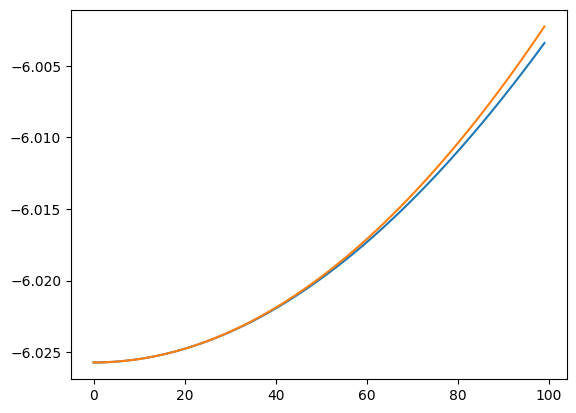

In [269]:
plt.plot(InterpolatedEnergies)
plt.plot(QuadraticEnergy)

In [62]:
def GetSO3MatrixForSDS(a1,b1,c1):
    #Backwards definitions for rotations. See canonical angles
    a = -a1
    b = -b1
    c = -c1
    #a then b then c
    #apply result to vector on right
    Kappa1 = np.array([[0,-np.sqrt(2),0],[np.sqrt(2),0,-np.sqrt(2)],[0,np.sqrt(2),0]]) # single exc
    Kappa2 = np.array([[0,0,-2],[0,0,0],[2,0,0]],dtype=np.float64) # double exc
    ret = np.identity(3)
    ret += 0.5*np.sin(2*a)*Kappa1 + 0.25*(1-np.cos(2*a)) * Kappa1 @ Kappa1
    ret += 0.5*np.sin(b)*Kappa2@ret + 0.25*(1-np.cos(b)) * Kappa2 @ Kappa2 @ ret
    ret += 0.5*np.sin(2*c)*Kappa1@ret + 0.25*(1-np.cos(2*c)) * Kappa1 @ Kappa1 @ ret
    return ret

def getAxisAngleFromMatrix(RotationMatrix):
    E,V = np.linalg.eig(RotationMatrix)
    AxisIndex = None
    for i,e in enumerate(E):
        if np.isclose(e,1):
            AxisIndex = i
    #The other two eigenvalues form a cos(theta) sin(theta) pair. 
    #We want this to be a right handed system with Z along the axis
    # print(E)
    # print(AxisIndex)
    Axis = (V[:,AxisIndex]).reshape(3)
    OtherVIndex = []

    for i in range(0,3):
        if not i == AxisIndex:
            OtherVIndex.append(i)
    RealPart = (V[:,OtherVIndex[0]] + V[:,OtherVIndex[1]]).real
    ImagPart = ((V[:,OtherVIndex[0]] - V[:,OtherVIndex[1]])/1j).real
    RealPart = RealPart/np.linalg.norm(RealPart)
    ImagPart = ImagPart/np.linalg.norm(ImagPart)
    CosTheta = np.real(E[OtherVIndex[0]])
    SinTheta = np.imag(E[OtherVIndex[0]]) #Sign ambiguity
    Theta = np.arctan2(SinTheta,CosTheta)
    return Axis,Theta




In [333]:
Paramter2Rotation = GetSO3MatrixForSDS(*ParameterList[2,3:6])

In [334]:
Paramter3Rotation = GetSO3MatrixForSDS(*ParameterList[3,3:6])

In [335]:
Paramter2Rotation

array([[ 0.74497955, -0.04706163,  0.66542518],
       [ 0.02105165,  0.99867013,  0.04706163],
       [-0.66675505, -0.02105165,  0.74497955]])

In [336]:
Paramter3Rotation

array([[ 0.84842082,  0.0375234 ,  0.52799063],
       [-0.02083496,  0.99907852, -0.0375234 ],
       [-0.5289121 ,  0.02083496,  0.84842082]])

In [337]:
Axis2,Angle2 = getAxisAngleFromMatrix(Paramter2Rotation)
Axis3,Angle3 = getAxisAngleFromMatrix(Paramter3Rotation)

In [338]:
Axis2

array([-0.05099604+0.j,  0.99739601+0.j,  0.05099604+0.j])

In [339]:
Axis3

array([-0.05504881+0.j, -0.99696502+0.j,  0.05504881+0.j])

Beautiful. This is a mirroring of the axis about the y direction. i.e. mirror the axis in the XZ plane. Note that a spatial inversion does not change the axis. Therefore this is  i C2 with the C2 about the Y axis. Indeed we can see this in the angles. 3->-3 and 5->-5. I.e. both the angles negated. In terms of sign changes to the wavefunction that occured?


The x has changed the sign in x,y. 

The y has changed the sign for x and z

The z has changed the sign for y

Interestingly, this is within canonical angles. Therefore we know the initial state was Z, 01|01. (Weirdness due to definition of operators) Therefore this is a Mirroring in the XZ plane, Same as for the axis
We can prove this by taking the energy hit on the converted 3->6 and plotting the energy as it converges to the T.S.

In [278]:
NumberOfInterpolationSteps = 100
InterpolationAngleStart = 3
InterpolationAngleEnd = 6
Step = (ParameterList[3,:] - ParameterList[2,:])/(NumberOfInterpolationSteps-1)
InterpolatedParameters = np.zeros((NumberOfInterpolationSteps,len(ParameterList[3,:])))
for i in range(0,NumberOfInterpolationSteps):
    InterpolatedParameters[i,:] = ParameterList[2,:] + Step * i
    InterpolatedParameters[i,InterpolationAngleStart:InterpolationAngleEnd] = ParameterList[3,InterpolationAngleStart:InterpolationAngleEnd]

In [279]:
InterpolatedEnergies = np.zeros(NumberOfInterpolationSteps)
for i in range(0,NumberOfInterpolationSteps):
    man.setAngles(InterpolatedParameters[i,:])
    InterpolatedEnergies[i] = man.getExpectationValue()


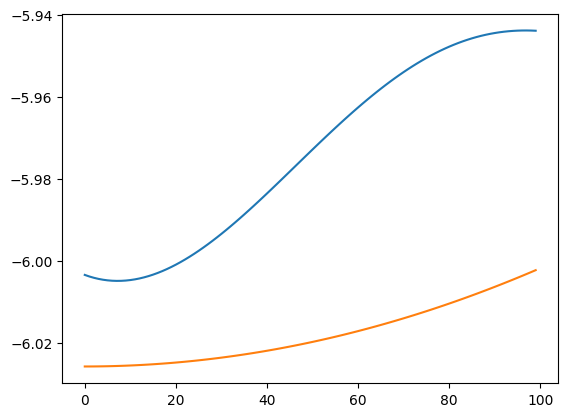

In [280]:
plt.plot(InterpolatedEnergies)
plt.plot(QuadraticEnergy)

Perhaps this is better?? I'm not convinced. Unfortunately I cant relax a pathway but I can optimise from the converted angles

In [288]:
ConvertedAngles = ParameterList[2,:].copy()
ConvertedAngles[InterpolationAngleStart:InterpolationAngleEnd] = ParameterList[3,InterpolationAngleStart:InterpolationAngleEnd]
man.setAngles(ConvertedAngles)
man.optimise()
ConvertedAnglesOptimised = man.getAngles()

Energy: -6.003404818 GradNorm: 0.267587 Time (ms): 1, Energy Evals: 2, Hess Evals: 1
Energy: -6.025141499 GradNorm: 0.0433571 Time (ms): 2, Energy Evals: 4, Hess Evals: 2
Energy: -6.025990673 GradNorm: 0.0333711 Time (ms): 1, Energy Evals: 6, Hess Evals: 3
Energy: -6.026341198 GradNorm: 0.00887754 Time (ms): 1, Energy Evals: 15, Hess Evals: 4
Energy: -6.026451451 GradNorm: 0.0115503 Time (ms): 0, Energy Evals: 17, Hess Evals: 5
Energy: -6.026576984 GradNorm: 0.014857 Time (ms): 0, Energy Evals: 19, Hess Evals: 6
Energy: -6.02672919 GradNorm: 0.00764274 Time (ms): 0, Energy Evals: 21, Hess Evals: 7
Energy: -6.026796209 GradNorm: 0.00996953 Time (ms): 0, Energy Evals: 23, Hess Evals: 8
Energy: -6.026884608 GradNorm: 0.0147688 Time (ms): 0, Energy Evals: 25, Hess Evals: 9
Energy: -6.02699516 GradNorm: 0.00349476 Time (ms): 1, Energy Evals: 29, Hess Evals: 10
Energy: -6.027033825 GradNorm: 0.00520206 Time (ms): 1, Energy Evals: 31, Hess Evals: 11
Energy: -6.027070981 GradNorm: 0.0069859 Ti

Better but not there yet. Lets look at the other side of the pathway. Optim says the high barrier still exists. Its probably correct

In [296]:
ParameterList[3,:]

array([ 0.10420773,  2.59699921, -0.10420773, -0.03896482,  0.55867142,
        0.03896482, -0.04258639,  0.40990697,  0.04258639,  2.38969994,
       -0.21967933, -0.21309467,  0.75106217,  3.23640013, -0.85509239,
       -0.52114417, -1.48044939, -2.39325452, -0.93378816,  1.87995738,
        1.07276345,  1.84315249, -2.36057176,  1.46025828,  1.67436451,
        0.27017552,  0.049443  , -3.03190712])

In [297]:
np. set_printoptions(suppress=True)
(ParameterList[4,:] - ParameterList[3,:])/ParameterList[3,:]

array([ 1.66992463, -0.0259786 ,  1.66992463,  0.96270642,  0.02019582,
        0.96270642, -1.03238361,  0.36045104, -1.03238361,  0.00793166,
        0.88769115,  0.38502665,  0.02333474, -0.09248054, -0.36076419,
        0.57584145, -0.35825723, -0.17216392, -0.18023242,  0.0061883 ,
        0.32131131,  0.04681073,  0.02223247, -0.22957087,  0.10754762,
       -0.63768239, -2.85649549, -0.10526815])

In [298]:
(ParameterList[4,:] - ParameterList[3,:])

array([ 0.17401905, -0.06746641, -0.17401905, -0.03751168,  0.01128283,
        0.03751168,  0.0439655 ,  0.14775139, -0.0439655 ,  0.01895428,
       -0.1950074 , -0.08204713,  0.01752584, -0.29930403,  0.30848672,
       -0.30009641,  0.5303817 ,  0.41203208,  0.1682989 ,  0.01163374,
        0.34469103,  0.08627931, -0.05248133, -0.33523276,  0.18007391,
       -0.17228617, -0.14123372,  0.31916325])

Nothing glaringly obvious, Some angles go to zero. Lets look at the overall change across the entire path

In [299]:
ParameterList[2,:]

array([ 0.12607741,  2.57540268, -0.12607741,  0.03609098,  0.73128836,
       -0.03609098, -0.04243146,  0.56222148,  0.04243146,  2.40007565,
       -0.11032179, -0.00464859,  0.81766441,  3.40274293, -1.14245946,
       -0.51572556, -1.68274831, -2.76548228, -1.12619031,  1.73682359,
        0.91555553,  2.01933414, -2.1436188 ,  1.54154103,  1.94160205,
        0.30978813,  0.20400048, -3.05271756])

In [300]:
np. set_printoptions(suppress=True)
(ParameterList[4,:] - ParameterList[2,:])/ParameterList[2,:]

array([ 1.20679319, -0.01781076,  1.20679319, -3.11899192, -0.22061627,
       -3.11899192, -1.03250186, -0.00811623, -1.03250186,  0.00357429,
        2.7588832 , 62.49063593, -0.06002022, -0.13684455, -0.52155355,
        0.59239843, -0.43540714, -0.28358881, -0.32028428,  0.08910953,
        0.54819062, -0.04452078,  0.12569133, -0.27019424, -0.04489263,
       -0.68401194, -1.44995343, -0.11136756])

In [301]:
(ParameterList[4,:] - ParameterList[2,:])

array([ 0.15214936, -0.04586988, -0.15214936, -0.11256748, -0.16133411,
        0.11256748,  0.04381056, -0.00456312, -0.04381056,  0.00857858,
       -0.30436494, -0.29049321, -0.0490764 , -0.46564684,  0.59585379,
       -0.30551502,  0.73268063,  0.78425984,  0.36070105,  0.15476754,
        0.50189895, -0.08990234, -0.26943429, -0.41651551, -0.08716362,
       -0.21189878, -0.29579119,  0.33997369])

Lets try axis angle for the 5 SDS at the start, Perhaps angle 26?

In [332]:
for s,e in [(0,3),(3,6),(6,9),(9,12),(12,15)]:
    AxisS,AngleS = getAxisAngleFromMatrix(GetSO3MatrixForSDS(*ParameterList[2,s:e]))
    AxisE,AngleE = getAxisAngleFromMatrix(GetSO3MatrixForSDS(*ParameterList[3,s:e]))
    print(f"S: {AngleS}:{AxisS}, E: {AngleE}:{AxisE}")


S: 2.575402679805011:[ 0.17641694+0.j -0.96837706+0.j -0.17641694+0.j], E: 2.5969992080533135:[ 0.1463074+0.j -0.97836  +0.j -0.1463074+0.j]
S: 0.7312883562706158:[-0.05099604+0.j  0.99739601+0.j  0.05099604+0.j], E: 0.5586714226383953:[-0.05504881+0.j -0.99696502+0.j  0.05504881+0.j]
S: 0.5622214819562743:[-0.05993514+0.j -0.9964013 +0.j  0.05993514+0.j], E: 0.4099069720272079:[-0.06015346+0.j -0.99637499+0.j  0.06015346+0.j]
S: 1.4956187799495182:[-0.66625638+0.j  0.06004131+0.j -0.74330174+0.j], E: 1.938311587415992:[ 0.65258502+0.j -0.11412888+0.j  0.74907101+0.j]
S: 2.894168371127888:[-0.68322306+0.j -0.37923351+0.j  0.62400977+0.j], E: 3.0472981120360725:[-0.71013956+0.j -0.03535044+0.j  0.70317292+0.j]


Angles 9-12 are suspicious. They go to their negatives. This is the same as negating the angle, but since the angles are both positive this is truely a different rotation. It is a negation of the angle. What if we fix this too and then try to converge

In [307]:
ConvertedAngles = ParameterList[2,:].copy()
ConvertedAngles[3:6] = ParameterList[3,3:6]
ConvertedAngles[9:12] = ParameterList[3,9:12]
man.setAngles(ConvertedAngles)
man.optimise()
ConvertedAnglesOptimised = man.getAngles()

Energy: -5.973412664 GradNorm: 0.494332 Time (ms): 1, Energy Evals: 2, Hess Evals: 1
Energy: -6.012201959 GradNorm: 0.218987 Time (ms): 2, Energy Evals: 5, Hess Evals: 2
Energy: -6.020758034 GradNorm: 0.147342 Time (ms): 1, Energy Evals: 7, Hess Evals: 3
Energy: -6.026349489 GradNorm: 0.0202555 Time (ms): 1, Energy Evals: 14, Hess Evals: 4
Energy: -6.02645323 GradNorm: 0.0194258 Time (ms): 0, Energy Evals: 16, Hess Evals: 5
Energy: -6.02662433 GradNorm: 0.0172959 Time (ms): 0, Energy Evals: 18, Hess Evals: 6
Energy: -6.026777942 GradNorm: 0.00828767 Time (ms): 0, Energy Evals: 21, Hess Evals: 7
Energy: -6.026835334 GradNorm: 0.00900483 Time (ms): 0, Energy Evals: 23, Hess Evals: 8
Energy: -6.026907146 GradNorm: 0.0116805 Time (ms): 0, Energy Evals: 25, Hess Evals: 9
Energy: -6.027006066 GradNorm: 0.00648553 Time (ms): 0, Energy Evals: 27, Hess Evals: 10
Energy: -6.027051123 GradNorm: 0.00824994 Time (ms): 0, Energy Evals: 29, Hess Evals: 11
Energy: -6.027112513 GradNorm: 0.00796642 Tim

nope, but it does get us up to the barrier. Lets check if the interpolation is flatter now

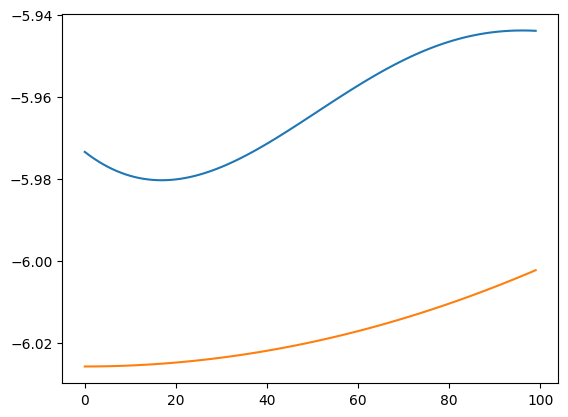

In [309]:
NumberOfInterpolationSteps = 100
Step = (ParameterList[3,:] - ParameterList[2,:])/(NumberOfInterpolationSteps-1)
InterpolatedParameters = np.zeros((NumberOfInterpolationSteps,len(ParameterList[3,:])))
for i in range(0,NumberOfInterpolationSteps):
    InterpolatedParameters[i,:] = ParameterList[2,:] + Step * i
    InterpolatedParameters[i,3:6] = ParameterList[3,3:6]
    InterpolatedParameters[i,9:12] = ParameterList[3,9:12]
InterpolatedEnergies = np.zeros(NumberOfInterpolationSteps)
for i in range(0,NumberOfInterpolationSteps):
    man.setAngles(InterpolatedParameters[i,:])
    InterpolatedEnergies[i] = man.getExpectationValue()
plt.plot(InterpolatedEnergies)
plt.plot(QuadraticEnergy)

Better but not there yet. 

In [331]:
for s,e in [(0,3),(3,6),(6,9),(9,12),(12,15)]:
    AxisS,AngleS = getAxisAngleFromMatrix(GetSO3MatrixForSDS(*ParameterList[2,s:e]))
    AxisE,AngleE = getAxisAngleFromMatrix(GetSO3MatrixForSDS(*ParameterList[4,s:e]))
    print(f"S: {AngleS}:{AxisS}, E: {AngleE}:{AxisE}")


S: 2.575402679805011:[ 0.17641694+0.j -0.96837706+0.j -0.17641694+0.j], E: 2.5295327964:[ 0.37347833+0.j -0.8491336 +0.j -0.37347833+0.j]
S: 0.7312883562706158:[-0.05099604+0.j  0.99739601+0.j  0.05099604+0.j], E: 0.5699542480999998:[-0.10773289+0.j -0.98832548+0.j  0.10773289+0.j]
S: 0.5622214819562743:[-0.05993514+0.j -0.9964013 +0.j  0.05993514+0.j], E: 0.5576583650000005:[-0.00195034+0.j  0.9999962 +0.j  0.00195034+0.j]
S: 1.4956187799495182:[-0.66625638+0.j  0.06004131+0.j -0.74330174+0.j], E: 2.081897742245061:[ 0.61517069+0.j -0.21607273+0.j  0.75820683+0.j]
S: 2.894168371127888:[-0.68322306+0.j -0.37923351+0.j  0.62400977+0.j], E: 2.9421307577135094:[-0.69992874+0.j  0.25276403+0.j  0.6679896 +0.j]


Looking at the full path from 2->4 shows that 12-15 also undergoes a mirroring in the Y direction. Lets try with that too:

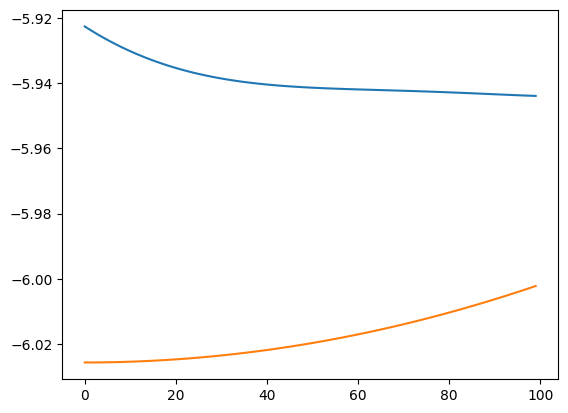

In [314]:
NumberOfInterpolationSteps = 100
Step = (ParameterList[3,:] - ParameterList[2,:])/(NumberOfInterpolationSteps-1)
InterpolatedParameters = np.zeros((NumberOfInterpolationSteps,len(ParameterList[3,:])))
for i in range(0,NumberOfInterpolationSteps):
    InterpolatedParameters[i,:] = ParameterList[2,:] + Step * i
    InterpolatedParameters[i,3:6] = ParameterList[3,3:6]
    InterpolatedParameters[i,9:12] = ParameterList[3,9:12]
    InterpolatedParameters[i,12:15] = ParameterList[3,12:15]
InterpolatedEnergies = np.zeros(NumberOfInterpolationSteps)
for i in range(0,NumberOfInterpolationSteps):
    man.setAngles(InterpolatedParameters[i,:])
    InterpolatedEnergies[i] = man.getExpectationValue()
plt.plot(InterpolatedEnergies)
plt.plot(QuadraticEnergy)

or between the global minimum and the T.S.

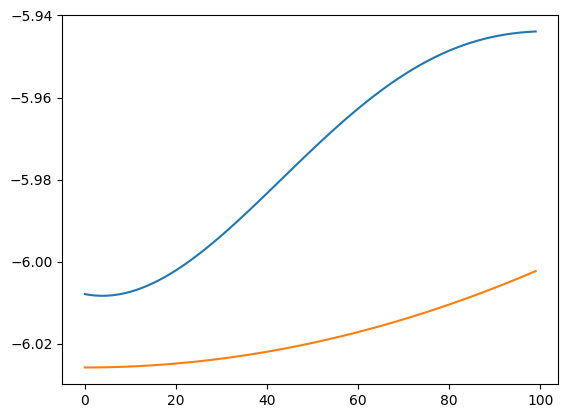

In [ ]:
NumberOfInterpolationSteps = 100
Step = (ParameterList[3,:] - ParameterList[4,:])/(NumberOfInterpolationSteps-1)
InterpolatedParameters = np.zeros((NumberOfInterpolationSteps,len(ParameterList[3,:])))
for i in range(0,NumberOfInterpolationSteps):
    InterpolatedParameters[i,:] = ParameterList[4,:] + Step * i
    InterpolatedParameters[i,3:6] = ParameterList[3,3:6]
    InterpolatedParameters[i,9:12] = ParameterList[3,9:12]
    InterpolatedParameters[i,12:15] = ParameterList[3,12:15]
InterpolatedEnergies = np.zeros(NumberOfInterpolationSteps)
for i in range(0,NumberOfInterpolationSteps):
    man.setAngles(InterpolatedParameters[i,:])
    InterpolatedEnergies[i] = man.getExpectationValue()
plt.plot(InterpolatedEnergies)
plt.plot(QuadraticEnergy)

Still a significant energy rise on the other side, but not this side. Lets look at the other side. 

In [330]:
for s,e in [(0,3),(3,6),(6,9),(9,12),(12,15)]:
    AxisS,AngleS = getAxisAngleFromMatrix(GetSO3MatrixForSDS(*ParameterList[3,s:e]))
    AxisE,AngleE = getAxisAngleFromMatrix(GetSO3MatrixForSDS(*ParameterList[4,s:e]))
    print(f"S: {AngleS}:{AxisS}, E: {AngleE}:{AxisE}")

S: 2.5969992080533135:[ 0.1463074+0.j -0.97836  +0.j -0.1463074+0.j], E: 2.5295327964:[ 0.37347833+0.j -0.8491336 +0.j -0.37347833+0.j]
S: 0.5586714226383953:[-0.05504881+0.j -0.99696502+0.j  0.05504881+0.j], E: 0.5699542480999998:[-0.10773289+0.j -0.98832548+0.j  0.10773289+0.j]
S: 0.4099069720272079:[-0.06015346+0.j -0.99637499+0.j  0.06015346+0.j], E: 0.5576583650000005:[-0.00195034+0.j  0.9999962 +0.j  0.00195034+0.j]
S: 1.938311587415992:[ 0.65258502+0.j -0.11412888+0.j  0.74907101+0.j], E: 2.081897742245061:[ 0.61517069+0.j -0.21607273+0.j  0.75820683+0.j]
S: 3.0472981120360725:[-0.71013956+0.j -0.03535044+0.j  0.70317292+0.j], E: 2.9421307577135094:[-0.69992874+0.j  0.25276403+0.j  0.6679896 +0.j]


This is just showing 9-12 which we knew already 

Lets try angle 26 from earlier - Nope, Not shown

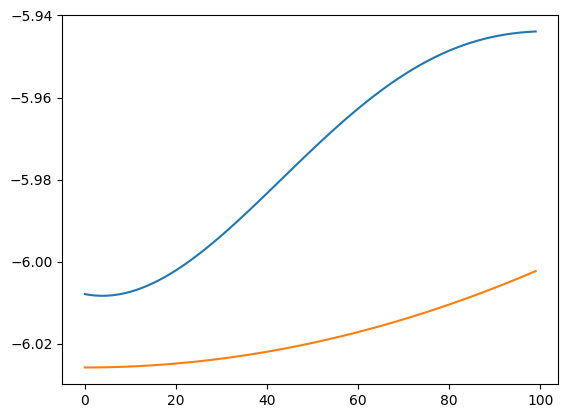

In [379]:
NumberOfInterpolationSteps = 100
Step = (ParameterList[3,:] - ParameterList[4,:])/(NumberOfInterpolationSteps-1)
InterpolatedParameters = np.zeros((NumberOfInterpolationSteps,len(ParameterList[3,:])))
for i in range(0,NumberOfInterpolationSteps):
    InterpolatedParameters[i,:] = ParameterList[4,:] + Step * i
    InterpolatedParameters[i,3:6] = ParameterList[3,3:6]
    InterpolatedParameters[i,9:12] = ParameterList[3,9:12]
    InterpolatedParameters[i,12:15] = ParameterList[3,12:15]
InterpolatedEnergies = np.zeros(NumberOfInterpolationSteps)
for i in range(0,NumberOfInterpolationSteps):
    man.setAngles(InterpolatedParameters[i,:])
    InterpolatedEnergies[i] = man.getExpectationValue()
plt.plot(InterpolatedEnergies)
plt.plot(QuadraticEnergy)

From trying all the angles it seems: 15,16,17,20,23,25ish,27 are important, These change by fairly large factors. 

In [378]:
np. set_printoptions(suppress=True)
ChangeFactor = (ParameterList[4,:] - ParameterList[3,:])/ParameterList[3,:]
ChangeFactor[[15,16,17,20,23,25,27]]

array([ 0.57584145, -0.35825723, -0.17216392,  0.32131131, -0.22957087,
       -0.63768239, -0.10526815])

In [449]:
ParameterList[4,[15,16,17,20,23,25,27]] - ParameterList[2,[15,16,17,20,23,25,27]]


array([-0.30551502,  0.73268063,  0.78425984,  0.50189895, -0.41651551,
       -0.21189878,  0.33997369])

In [561]:
ConvertedAngles = ParameterList[2,:].copy()
# ConvertedAngles[0:3] = ParameterList[2,0:3]
# ConvertedAngles[3:6] = ParameterList[2,3:6]
# ConvertedAngles[6:9] = ParameterList[2,6:9]
# ConvertedAngles[9:12] = ParameterList[2,9:12]
# ConvertedAngles[12:15] = ParameterList[2,12:15]
# ConvertedAngles[15] = ParameterList[4,15]
# ConvertedAngles[16] = ParameterList[4,16]
# ConvertedAngles[17] = ParameterList[4,17]
# ConvertedAngles[20] = ParameterList[4,20]
# ConvertedAngles[15] += np.pi/2
ConvertedAngles[16] += np.pi/4
ConvertedAngles[17] += np.pi/4
# ConvertedAngles[20] += np.pi
# ConvertedAngles[21] += np.pi
# ConvertedAngles[22] += np.pi

# ConvertedAngles[25] += np.pi
# ConvertedAngles[26] += np.pi
# ConvertedAngles[27] += np.pi

# ConvertedAngles[23] = ParameterList[4,23]
# ConvertedAngles[25] = ParameterList[4,25]
# ConvertedAngles[27] = ParameterList[4,27]
man.setAngles(ConvertedAngles)
man.optimise()
ConvertedAnglesOptimised = man.getAngles()

Energy: -5.475424672 GradNorm: 1.03358 Time (ms): 1, Energy Evals: 6, Hess Evals: 1
Energy: -5.585192878 GradNorm: 0.912725 Time (ms): 1, Energy Evals: 11, Hess Evals: 2
Energy: -5.686842614 GradNorm: 0.697661 Time (ms): 1, Energy Evals: 15, Hess Evals: 3
Energy: -5.856776355 GradNorm: 0.590427 Time (ms): 1, Energy Evals: 19, Hess Evals: 4
Energy: -5.920652929 GradNorm: 0.305629 Time (ms): 1, Energy Evals: 21, Hess Evals: 5
Energy: -5.966246796 GradNorm: 0.205058 Time (ms): 1, Energy Evals: 24, Hess Evals: 6
Energy: -6.01530575 GradNorm: 0.243484 Time (ms): 1, Energy Evals: 30, Hess Evals: 7
Energy: -6.028154484 GradNorm: 0.222414 Time (ms): 1, Energy Evals: 32, Hess Evals: 8
Energy: -6.044905677 GradNorm: 0.0444961 Time (ms): 0, Energy Evals: 34, Hess Evals: 9
Energy: -6.046078604 GradNorm: 0.010368 Time (ms): 0, Energy Evals: 36, Hess Evals: 10
Energy: -6.046918991 GradNorm: 0.0182561 Time (ms): 0, Energy Evals: 38, Hess Evals: 11
Energy: -6.051579233 GradNorm: 0.0294205 Time (ms): 0

In [31]:
def dneb(startAngles, EndAngles, numberOfSteps,dnebSteps):
    forceConstant = 1
    gradStepSize = 0.1
    positions = np.zeros((numberOfSteps,len(startAngles)))
    step = (EndAngles-startAngles)/(numberOfSteps-1)
    for i in range(0,numberOfSteps):
        positions[i,:] = startAngles + step * i
    for _ in range(0,dnebSteps):
        grads = np.zeros((numberOfSteps,len(startAngles)))
        for i in range(0,numberOfSteps):
            man.setAngles(positions[i,:])
            grads[i,:] = man.getGradientComp()
        for i in range(1,numberOfSteps-1):
            # d/dx1 0.5 k(x2-x1)^2 = k(x1-x2)
            # d/dx2 0.5 k(x2-x1)^2 = k(x2-x1)
            displacementBackward = positions[i,:] - positions[i-1,:]
            displacementForward = positions[i,:] - positions[i+1,:]
            grads[i,:] += forceConstant * (displacementForward + displacementBackward)
        grads[0,:] = 0
        grads[-1,:] = 0
        #update
        for i in range(1,numberOfSteps-1):
            positions[i,:] += -gradStepSize * grads[i,:]
    return positions
        
    

In [87]:
def readPathInfoFile(filename,numParameters):
    Energies = []
    Coords = []
    pos = 0
    STATE = "ENERGY"
    HILLPOS = "MinL"
    with open(filename) as f:
        for line in f:
            # print(f"Read:{line}")
            # print(f"STATE:{STATE}")
            # print(f"HILLPOS:{HILLPOS}")
            # print(f"pos:{pos}")
            if STATE == "ENERGY":            
                Energy = float(line)
                if (HILLPOS == "MinL"):
                    Energies.append([Energy])
                else:
                    Energies[-1].append(Energy)
                STATE = "SKIPSYM"
                continue
            if STATE=="SKIPSYM":
                STATE="COORDS"
                pos = 0
                continue
            if STATE=="COORDS":
                splitLine = line.split()
                parsedCoords = [float(s) for s in splitLine[:min(3,len(splitLine))]]
                if (pos == 0):
                    if (HILLPOS == "MinL"):
                        Coords.append([])    
                    Coords[-1].append([])
                for c in parsedCoords:
                    Coords[-1][-1].append(c)
                pos += len(parsedCoords)
                if (pos == numParameters):
                    STATE="ENERGY"
                    if (HILLPOS == "MinL"):
                        HILLPOS = "TS"
                    elif (HILLPOS == "TS"):
                        HILLPOS = "MinR"
                    elif (HILLPOS == "MinR"):
                        HILLPOS = "MinL"
                    pos = 0
    
    return Energies,Coords

def SetCorrAnglesToRHS(LHS,RHS):
    LHS[:11] = RHS[:11]
    LHS[12:14] = RHS[12:14]

def SetOOAnglesToRHS(LHS,RHS):
    LHS[11] = RHS[11]
    LHS[14:] = RHS[14:]

def SetCorrAnglesToZero(LHS,RHS):
    LHS[:11] = 0
    RHS[:11] = 0
    LHS[12:14] = 0
    RHS[12:14] = 0


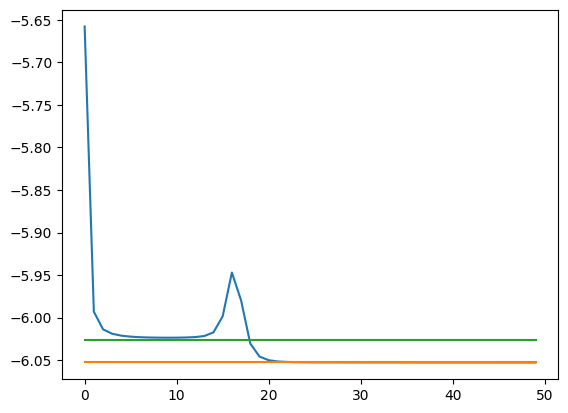

In [22]:
StartAngle1 = ParameterList[2,:].copy()
StartAngle1[0:3] = ParameterList[4,0:3]
StartAngle1[3:6] = ParameterList[4,3:6]
StartAngle1[6:9] = ParameterList[4,6:9]
StartAngle1[9:12] = ParameterList[4,9:12]
StartAngle1[12:15] = ParameterList[4,12:15]

# StartAngle1[11] = ParameterList[4,11]
# StartAngle1[14] = ParameterList[4,14]
# StartAngle1[15] = ParameterList[4,15]
# StartAngle1[16] = ParameterList[4,16]
# StartAngle1[17] = ParameterList[4,17]
# StartAngle1[18] = ParameterList[4,18]
# StartAngle1[19] = ParameterList[4,19]
# StartAngle1[20] = ParameterList[4,20]
# StartAngle1[21] = ParameterList[4,21]
# StartAngle1[22] = ParameterList[4,22]
# StartAngle1[23] = ParameterList[4,23]
# StartAngle1[24] = ParameterList[4,24]
# StartAngle1[25] = ParameterList[4,25]
# StartAngle1[26] = ParameterList[4,26]
# StartAngle1[27] = ParameterList[4,27]
# StartAngle1[16] += np.pi/4
# StartAngle1[17] += np.pi/4
# StartAngle1[:11] = 0
# StartAngle1[12:14] = 0

EndAngle1 = ParameterList[4,:].copy()
# EndAngle1[:11] = 0
# EndAngle1[12:14] = 0
# EndAngle1[0:3] = ParameterList[2,0:3]
# EndAngle1[3:6] = ParameterList[2,3:6]
# EndAngle1[6:9] = ParameterList[2,6:9]
# EndAngle1[9:12] = ParameterList[2,9:12]
# EndAngle1[12:15] = ParameterList[2,12:15]

interpolationPoints = dneb(StartAngle1,EndAngle1,50,200)
InterpolatedEnergies = np.zeros(interpolationPoints.shape[0])
for i in range(0,interpolationPoints.shape[0]):
    man.setAngles(interpolationPoints[i,:])
    InterpolatedEnergies[i] = man.getExpectationValue()
plt.plot(InterpolatedEnergies)

plt.plot([-6.052720744]*len(InterpolatedEnergies))
plt.plot([-6.025724990225]*len(InterpolatedEnergies))

Text(0.5, 1.0, 'DNEB between LHS and RHS')

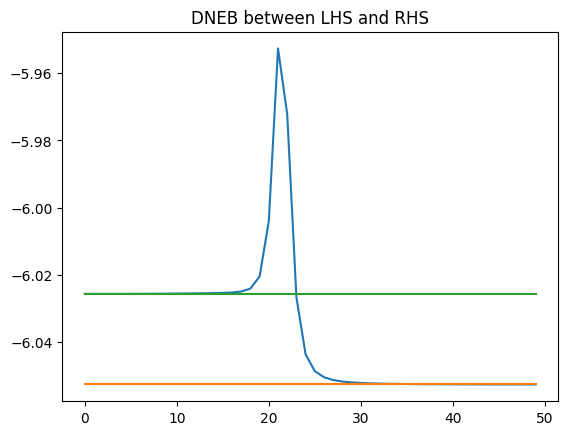

In [80]:
StartAngle1 = ParameterList[2,:].copy()
EndAngle1 = ParameterList[4,:].copy()

interpolationPoints = dneb(StartAngle1,EndAngle1,50,200)
InterpolatedEnergies = np.zeros(interpolationPoints.shape[0])
for i in range(0,interpolationPoints.shape[0]):
    man.setAngles(interpolationPoints[i,:])
    InterpolatedEnergies[i] = man.getExpectationValue()
plt.plot(InterpolatedEnergies)

plt.plot([-6.052720744]*len(InterpolatedEnergies))
plt.plot([-6.025724990225]*len(InterpolatedEnergies))
plt.title("DNEB between LHS and RHS")

Text(0.5, 1.0, 'DNEB between LHS and RHS with CorrAngles set to rhs')

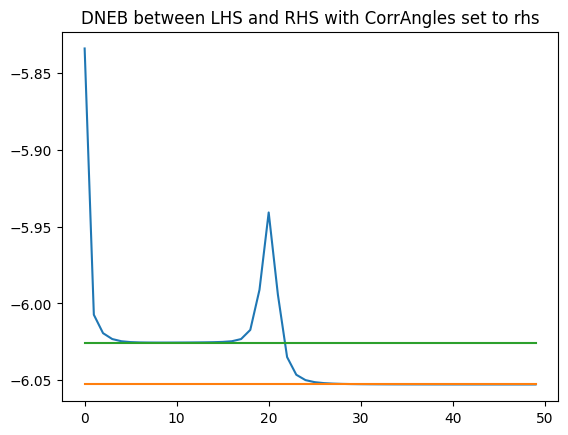

In [82]:
StartAngle1 = ParameterList[2,:].copy()
EndAngle1 = ParameterList[4,:].copy()

SetCorrAnglesToRHS(StartAngle1,EndAngle1)

interpolationPoints = dneb(StartAngle1,EndAngle1,50,200)
InterpolatedEnergies = np.zeros(interpolationPoints.shape[0])
for i in range(0,interpolationPoints.shape[0]):
    man.setAngles(interpolationPoints[i,:])
    InterpolatedEnergies[i] = man.getExpectationValue()
plt.plot(InterpolatedEnergies)

plt.plot([-6.052720744]*len(InterpolatedEnergies))
plt.plot([-6.025724990225]*len(InterpolatedEnergies))
plt.title("DNEB between LHS and RHS with CorrAngles set to rhs")

Text(0.5, 1.0, 'DNEB between LHS and RHS with CorrAngles set to zero')

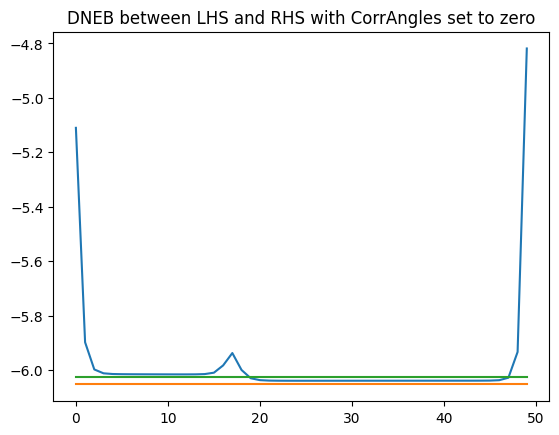

In [83]:
StartAngle1 = ParameterList[2,:].copy()
EndAngle1 = ParameterList[4,:].copy()

SetCorrAnglesToZero(StartAngle1,EndAngle1)

interpolationPoints = dneb(StartAngle1,EndAngle1,50,200)
InterpolatedEnergies = np.zeros(interpolationPoints.shape[0])
for i in range(0,interpolationPoints.shape[0]):
    man.setAngles(interpolationPoints[i,:])
    InterpolatedEnergies[i] = man.getExpectationValue()
plt.plot(InterpolatedEnergies)

plt.plot([-6.052720744]*len(InterpolatedEnergies))
plt.plot([-6.025724990225]*len(InterpolatedEnergies))
plt.title("DNEB between LHS and RHS with CorrAngles set to zero")

Text(0.5, 1.0, 'DNEB between LHS and RHS with OO Angles set to rhs')

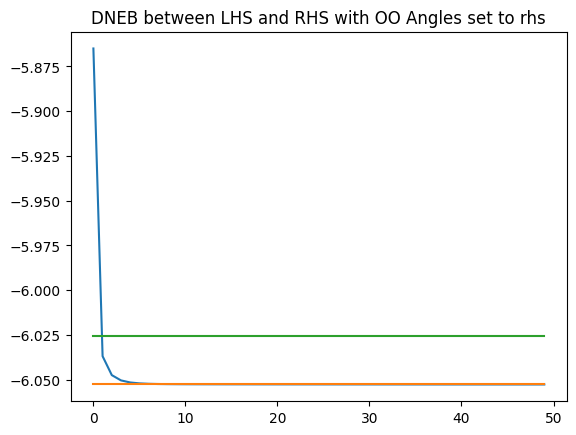

In [89]:
StartAngle1 = ParameterList[2,:].copy()
EndAngle1 = ParameterList[4,:].copy()

SetOOAnglesToRHS(StartAngle1,EndAngle1)

interpolationPoints = dneb(StartAngle1,EndAngle1,50,200)
InterpolatedEnergies = np.zeros(interpolationPoints.shape[0])
for i in range(0,interpolationPoints.shape[0]):
    man.setAngles(interpolationPoints[i,:])
    InterpolatedEnergies[i] = man.getExpectationValue()
plt.plot(InterpolatedEnergies)

plt.plot([-6.052720744]*len(InterpolatedEnergies))
plt.plot([-6.025724990225]*len(InterpolatedEnergies))
plt.title("DNEB between LHS and RHS with OO Angles set to rhs")

In [9]:
HartreeFockangles = np.zeros((28))
man.setAngles(HartreeFockangles)
man.getExpectationValue()

-5.660696841849897

In [10]:
HartreeFock0 = ParameterList[0,:].copy()
HartreeFock0[:11] = 0
HartreeFock0[12:14] = 0
man.setAngles(HartreeFock0)
man.getExpectationValue()

-4.989800212511417

In [11]:
HartreeFock1 = ParameterList[1,:].copy()
HartreeFock1[:11] = 0
HartreeFock1[12:14] = 0
man.setAngles(HartreeFock1)
man.getExpectationValue()

-5.015649021633513

In [12]:
HartreeFock2 = ParameterList[2,:].copy()
HartreeFock2[:11] = 0
HartreeFock2[12:14] = 0
man.setAngles(HartreeFock2)
man.getExpectationValue()

-5.110028410777662

In [13]:
HartreeFock3 = ParameterList[3,:].copy()
HartreeFock3[:11] = 0
HartreeFock3[12:14] = 0
man.setAngles(HartreeFock3)
man.getExpectationValue()

-4.9879321593317805

In [14]:
HartreeFock4 = ParameterList[4,:].copy()
HartreeFock4[:11] = 0
HartreeFock4[12:14] = 0
man.setAngles(HartreeFock4)
man.getExpectationValue()

-4.818517331202919

In [119]:
EnergyInPath,CoordsInPath = readPathInfoFile(PathBase + "path.info_m1_m3_s5_f12",NumParameters)
for step in range(len(CoordsInPath)):
    for i in range(3):
        Angles = CoordsInPath[step][i]
        man.setAngles(Angles)
        Angles = man.getUncompressedAngles()
        Angles = CanonicaliseAngles(man,Angles,Operators,SDSPositions,InitialStateCoeffs,InitialStateIndices)
        man.setAngles(Angles)
        CoordsInPath[step][i] = man.getAngles()

TS 21 i.e. index 20 is the one with the high barrier,   

21       -6.0524371  0.17360          -5.8788354  0.15100          -6.0298393   4.519   4.519   1.371  20.424

Text(0.5, 1.0, "DNEB joining 'Single step path'")

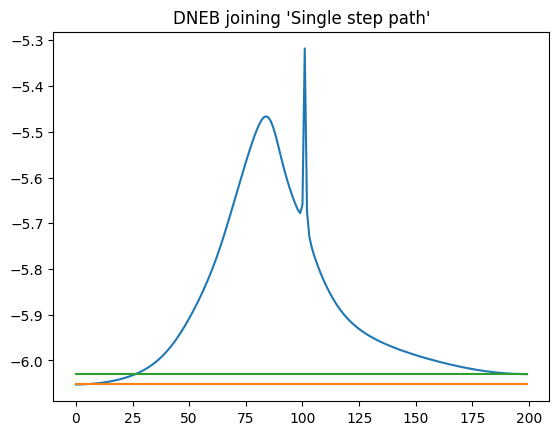

In [133]:
StartAngle1 = np.array(CoordsInPath[20][0])
EndAngle1 = np.array(CoordsInPath[20][2])



interpolationPoints = dneb(StartAngle1,EndAngle1,200,10)
InterpolatedEnergies = np.zeros(interpolationPoints.shape[0])
for i in range(0,interpolationPoints.shape[0]):
    man.setAngles(interpolationPoints[i,:])
    InterpolatedEnergies[i] = man.getExpectationValue()
plt.plot(InterpolatedEnergies)

plt.plot([EnergyInPath[20][0]]*len(InterpolatedEnergies))
plt.plot([EnergyInPath[20][2]]*len(InterpolatedEnergies))
plt.title("DNEB joining 'Single step path'")

In [ ]:
for c in CoordsInPath[20][2]:
    print(c)

0.6259433529231534
2.1912399302045733
-0.6259433529231534
0.0768453763103062
0.5699427291054486
-0.0768453763103062
-0.0015042579778786023
0.55824402013759
0.0015042579778786023
0.828580515765732
-0.507371160495664
0.506744048709954
2.37202634223833
2.93695505107179
-2.37518021088181
1.23015333240609
1.23190735592128
-2.4891172257598
-1.97267255522689
-1.03567587614448
0.770458279061782
-2.38455055829317
1.29103913232986
-2.03220338314681
-1.20074102853471
0.223115539667859
3.06391375424059
0.920734088290636


Text(0.5, 1.0, "DNEB joining 'Single step path' with CORR angles of rhs")

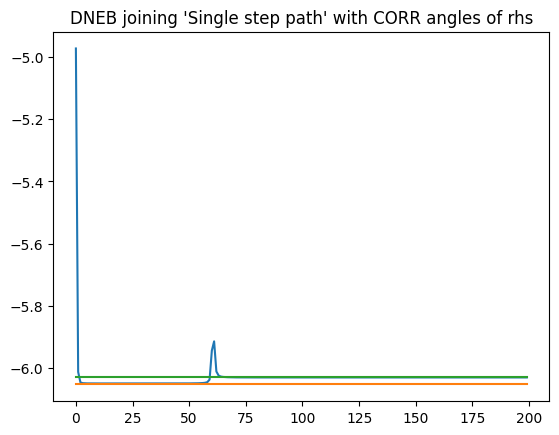

In [121]:
StartAngle1 = np.array(CoordsInPath[20][0])
EndAngle1 = np.array(CoordsInPath[20][2])
SetCorrAnglesToRHS(StartAngle1,EndAngle1)

interpolationPoints = dneb(StartAngle1,EndAngle1,200,1000)
InterpolatedEnergies = np.zeros(interpolationPoints.shape[0])
for i in range(0,interpolationPoints.shape[0]):
    man.setAngles(interpolationPoints[i,:])
    InterpolatedEnergies[i] = man.getExpectationValue()
plt.plot(InterpolatedEnergies)

plt.plot([EnergyInPath[20][0]]*len(InterpolatedEnergies))
plt.plot([EnergyInPath[20][2]]*len(InterpolatedEnergies))
plt.title("DNEB joining 'Single step path' with CORR angles of rhs")

Text(0.5, 1.0, "DNEB joining 'Single step path' with OO angles of rhs")

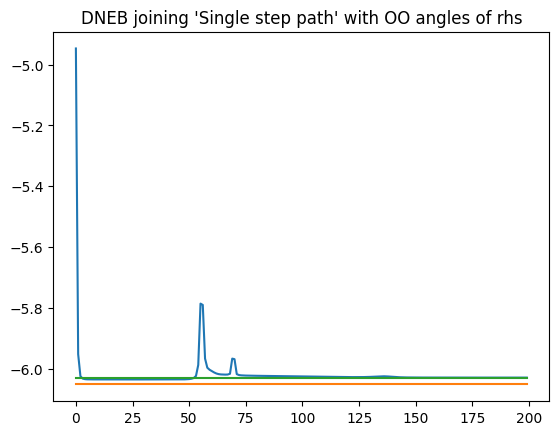

In [122]:
StartAngle1 = np.array(CoordsInPath[20][0])
EndAngle1 = np.array(CoordsInPath[20][2])
SetOOAnglesToRHS(StartAngle1,EndAngle1)
# StartAngle1[6:9] = EndAngle1[6:9]

interpolationPoints = dneb(StartAngle1,EndAngle1,200,1000)
InterpolatedEnergies = np.zeros(interpolationPoints.shape[0])
for i in range(0,interpolationPoints.shape[0]):
    man.setAngles(interpolationPoints[i,:])
    InterpolatedEnergies[i] = man.getExpectationValue()
plt.plot(InterpolatedEnergies)

plt.plot([EnergyInPath[20][0]]*len(InterpolatedEnergies))
plt.plot([EnergyInPath[20][2]]*len(InterpolatedEnergies))
plt.title("DNEB joining 'Single step path' with OO angles of rhs")

Text(0.5, 1.0, "DNEB joining 'Single step path' with OO angles of rhs + angles 7-9 of rhs")

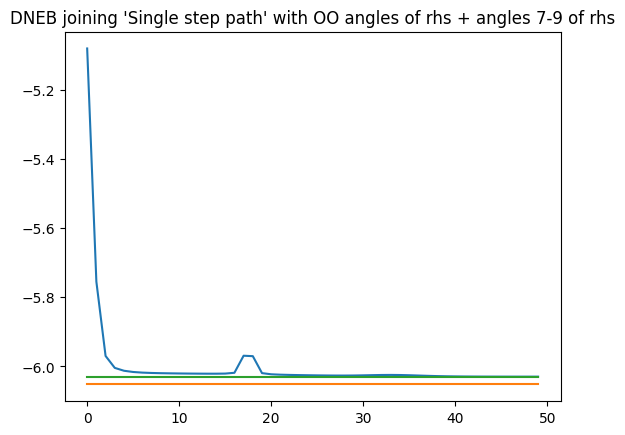

In [131]:
StartAngle1 = np.array(CoordsInPath[20][0])
EndAngle1 = np.array(CoordsInPath[20][2])
SetOOAnglesToRHS(StartAngle1,EndAngle1)
StartAngle1[6:9] = EndAngle1[6:9]

interpolationPoints = dneb(StartAngle1,EndAngle1,50,1000)
InterpolatedEnergies = np.zeros(interpolationPoints.shape[0])
for i in range(0,interpolationPoints.shape[0]):
    man.setAngles(interpolationPoints[i,:])
    InterpolatedEnergies[i] = man.getExpectationValue()
plt.plot(InterpolatedEnergies)

plt.plot([EnergyInPath[20][0]]*len(InterpolatedEnergies))
plt.plot([EnergyInPath[20][2]]*len(InterpolatedEnergies))
plt.title("DNEB joining 'Single step path' with OO angles of rhs + angles 7-9 of rhs")

In [124]:
getAxisAngleFromMatrix(GetSO3MatrixForSDS(*CoordsInPath[20][0][6:9]))

(array([-0.00212734+0.j, -0.99999547+0.j,  0.00212734+0.j]),
 np.float64(0.5582440201375902))

In [125]:
getAxisAngleFromMatrix(GetSO3MatrixForSDS(*CoordsInPath[20][2][6:9]))

(array([ 0.57059824+0.j, -0.5906228 +0.j, -0.57059824+0.j]),
 np.float64(2.390396190550325))

Text(0.5, 1.0, "DNEB joining 'Single step path' with CORR angles of Zero")

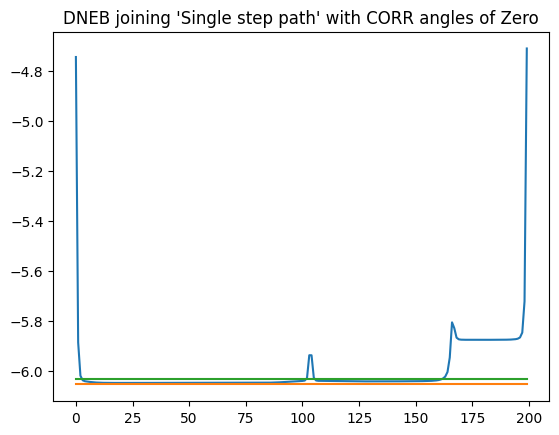

In [126]:
StartAngle1 = np.array(CoordsInPath[20][0])
EndAngle1 = np.array(CoordsInPath[20][2])
SetCorrAnglesToZero(StartAngle1,EndAngle1)

interpolationPoints = dneb(StartAngle1,EndAngle1,200,1000)
InterpolatedEnergies = np.zeros(interpolationPoints.shape[0])
for i in range(0,interpolationPoints.shape[0]):
    man.setAngles(interpolationPoints[i,:])
    InterpolatedEnergies[i] = man.getExpectationValue()
plt.plot(InterpolatedEnergies)

plt.plot([EnergyInPath[20][0]]*len(InterpolatedEnergies))
plt.plot([EnergyInPath[20][2]]*len(InterpolatedEnergies))
plt.title("DNEB joining 'Single step path' with CORR angles of Zero")